# Computer Exercise 5.4 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.4 Romberg Integration — *부드러움이 깨지면 사다리도 무너진다*
> **풀이 일자**: Day 20
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **3.** Apply your Romberg routine to **non-smooth** integrals:
> $$
> I_a = \int_0^1 \!\!\sqrt{x}\,dx = \tfrac{2}{3}, \qquad
> I_b = \int_0^1 \!\!\frac{1}{\sqrt{x}}\,dx = 2, \qquad
> I_c = \int_0^1 |x - \tfrac12|\,dx = \tfrac14.
> $$
> (a) Build the Romberg table and observe how the *column-wise convergence order* degrades.
> (b) For $I_a, I_b$, apply the change of variable $x = u^2$ to *regularize* the endpoint
>     singularity, and re-run Romberg on the transformed integrand.
> (c) Compare the *recovered* order to the smooth-integrand benchmark from Problem 1.
> Discuss when Romberg's $h^2$-only Euler–Maclaurin expansion fails and what a
> well-chosen substitution buys back.

### 한국어 풀이용 정리
- 사다리꼴의 Euler–Maclaurin 전개는 $f \in C^{\infty}$ 를 *결정적으로* 요구. 깨지면 *차수가 사라진다*.
- $\sqrt x$: 끝점 미분 발산 → $T_n - I = c\, h^{3/2} + \ldots$ — Romberg 가 $h^2$ 항을 *없다고 가정* 해서 헛수고.
- $1/\sqrt x$: 함수 자체가 발산 → 더 심함 ($h^{1/2}$).
- $|x - 1/2|$: 내부 꺾임 — 부분 사다리꼴은 *그 점만 그리드에 닿으면* 정확.
- *변수 변환* $x = u^2$ 은 $\sqrt x \to u$, $1/\sqrt x \to 2$ — *완전한 부드러움 복원* 으로 차수 사다리 부활.


## 2. 수학적 배경

### 2.1 Romberg 의 가정 — Euler–Maclaurin 의 *짝수* 차수

$$
T_n(f) - I \;=\; c_1 h^2 + c_2 h^4 + c_3 h^6 + \ldots
$$

는 $f \in C^{\infty}[a,b]$ *그리고* 끝점 도함수가 유한할 때만 성립. 이 가정이 깨지면:

| 함수 | 실제 점근 | Romberg 의 가정 | 결과 |
|---|---|---|---|
| $\sqrt x$ on $[0,1]$ | $T_n - I = -\zeta(-1/2)\,h^{3/2}/n^0 + \ldots$ | $h^2$ | 0열 기울기 $-3/2$, 1열도 $-3/2$ |
| $1/\sqrt x$ on $[0,1]$ | $T_n - I = c\,h^{1/2} + \ldots$ | $h^2$ | 1/2 차수, 모든 열 동일 |
| $\|x-1/2\|$ on $[0,1]$ | 격자가 $1/2$ 통과: 0; 아니면 $h^2$ | $h^2$ | 짝수 $i$ 에서 정확, 홀수 $i$ 에서 약함 |

### 2.2 변수 변환의 효과
$x = u^2$, $dx = 2u\,du$:

$$
\int_0^1 \sqrt x\,dx = \int_0^1 u \cdot 2u\,du = \int_0^1 2u^2\,du, \qquad
\int_0^1 \frac{1}{\sqrt x}\,dx = \int_0^1 \frac{1}{u} \cdot 2u\,du = \int_0^1 2\,du.
$$

피적분 함수가 $C^{\infty}$ 다항식 (또는 상수) — *완전한* 부드러움. Romberg 가 다시 *모든 차수* 의 점프 복원.

### 2.3 일반화 — *graded mesh* 와 *Möbius* 형 변환
$f \sim x^{\alpha}$ at $x = 0$ 이면 $x = u^{1/(1+\alpha)}$ (예: $\alpha = 1/2$ 면 $x = u^{2/3}$) 가 *최적 차수* 복원.
실무에서는 `scipy.integrate.quad` 가 *내부적으로* 끝점 변환을 적용 — 본 노트북의 한 단계 손계산이 그것의
*최소 모델*.

### 2.4 진단 도구
*열별 측정 기울기* — 1, 2, 3 열의 log–log 기울기가 *모두 같으면* (보통 $-3/2$ 또는 $-1/2$),
"$h^2$ 항이 없다" 는 결론. 즉 Romberg 가 *외삽할 게 없다*.


## 3. 풀이 흐름

1. 세 적분의 참값 정의 — $2/3$, $2$, $1/4$.
2. Day 20-Problem 1 의 `romberg_table` 그대로 사용. $k_{\max} = 12$.
3. 세 함수 각각에 대해 Romberg 표 생성 → 열별 오차 $|T[i,j]-I|$ 표 / 그림.
4. 열별 log–log 기울기 측정 — *모든 열이 같은 기울기* 이면 Romberg 외삽 무효.
5. $\sqrt x$, $1/\sqrt x$ 에 대해 *변환된* 피적분 함수 $\tilde f(u) = 2 u^2$ 또는 $\tilde f(u) = 2$ 로
   Romberg 재실행 → 차수 *복원* 확인.
6. $|x-1/2|$ 의 *기우 행* 효과 — 짝수 $i$ (즉 격자가 $1/2$ 점을 정확히 통과) 와 홀수 $i$ 비교.
7. 세 *원본* 결과와 두 *변환* 결과를 같은 그래프에 — *부드러움 회복의 가시화*.
8. 결론: Romberg 의 가정이 깨질 때 *적응형* (Day 19) 와 *변환* 의 두 길.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

def trapezoid_column(f, a, b, k_max):
    T0 = np.empty(k_max + 1)
    T0[0] = 0.5 * (b - a) * (f(a) + f(b))
    for i in range(1, k_max + 1):
        n_prev = 2 ** (i - 1)
        h = (b - a) / (2 ** i)
        xs = a + (2 * np.arange(n_prev) + 1) * h
        T0[i] = 0.5 * T0[i - 1] + h * f(xs).sum()
    return T0

def romberg_table(f, a, b, k_max):
    T = np.full((k_max + 1, k_max + 1), np.nan)
    T[:, 0] = trapezoid_column(f, a, b, k_max)
    for j in range(1, k_max + 1):
        for i in range(j, k_max + 1):
            T[i, j] = T[i, j - 1] + (T[i, j - 1] - T[i - 1, j - 1]) / (4.0 ** j - 1.0)
    return T

K_MAX = 12

# 1/sqrt(x) 는 x=0 에서 발산 — 끝점 처리: f(0) := 0 (사다리꼴이 측정하는 것은 a+ε 의 값 보간)
def f_sqrt(x):
    return np.sqrt(np.maximum(x, 0.0))

def f_invsqrt(x):
    x = np.asarray(x, dtype=float)
    out = np.where(x > 0, 1.0 / np.sqrt(np.maximum(x, 1e-300)), 0.0)
    return out

def f_abs(x):
    return np.abs(x - 0.5)

problems = [
    ("sqrt(x) on [0,1]",       f_sqrt,    0.0, 1.0, 2.0/3.0),
    ("1/sqrt(x) on [0,1]",     f_invsqrt, 0.0, 1.0, 2.0),
    ("|x - 1/2| on [0,1]",     f_abs,     0.0, 1.0, 0.25),
]

tables = {}
for name, f, a, b, I in problems:
    T = romberg_table(f, a, b, K_MAX)
    tables[name] = (T, I)
    print(f"{name:28s}   I = {I:.12f}   T[K,K] = {T[K_MAX, K_MAX]:.12f}    err = {abs(T[K_MAX,K_MAX]-I):.3e}")


sqrt(x) on [0,1]               I = 0.666666666667   T[K,K] = 0.666666405132    err = 2.615e-07
1/sqrt(x) on [0,1]             I = 2.000000000000   T[K,K] = 1.981042415572    err = 1.896e-02
|x - 1/2| on [0,1]             I = 0.250000000000   T[K,K] = 0.250000000000    err = 0.000e+00


In [2]:
# 각 문제의 처음 4열 오차 표 + 기울기
i_vals = np.arange(K_MAX + 1)
n_vals = 2.0 ** i_vals

def column_slope(err, n):
    mask = err > 1e-15
    if mask.sum() < 3:
        return np.nan
    s, _ = np.polyfit(np.log10(n[mask]), np.log10(err[mask]), 1)
    return s

slope_rows = []
for name, _, _, _, _ in problems:
    T, I = tables[name]
    for j in range(0, 5):
        err = np.abs(T[j:, j] - I)
        s = column_slope(err, n_vals[j:])
        slope_rows.append({
            "problem": name,
            "j": j,
            "slope (log|err| vs log n)": f"{s:+.3f}" if not np.isnan(s) else "n/a",
            "ideal smooth": f"-{2*(j+1)}",
        })
print("\n[Column-wise log-log slopes — compare to ideal -2(j+1)]\n")
print(pd.DataFrame(slope_rows).to_string(index=False))



[Column-wise log-log slopes — compare to ideal -2(j+1)]

           problem  j slope (log|err| vs log n) ideal smooth
  sqrt(x) on [0,1]  0                    -1.478           -2
  sqrt(x) on [0,1]  1                    -1.500           -4
  sqrt(x) on [0,1]  2                    -1.500           -6
  sqrt(x) on [0,1]  3                    -1.500           -8
  sqrt(x) on [0,1]  4                    -1.500          -10
1/sqrt(x) on [0,1]  0                    -0.502           -2
1/sqrt(x) on [0,1]  1                    -0.500           -4
1/sqrt(x) on [0,1]  2                    -0.500           -6
1/sqrt(x) on [0,1]  3                    -0.500           -8
1/sqrt(x) on [0,1]  4                    -0.500          -10
|x - 1/2| on [0,1]  0                       n/a           -2
|x - 1/2| on [0,1]  1                       n/a           -4
|x - 1/2| on [0,1]  2                       n/a           -6
|x - 1/2| on [0,1]  3                       n/a           -8
|x - 1/2| on [0,1]  4      

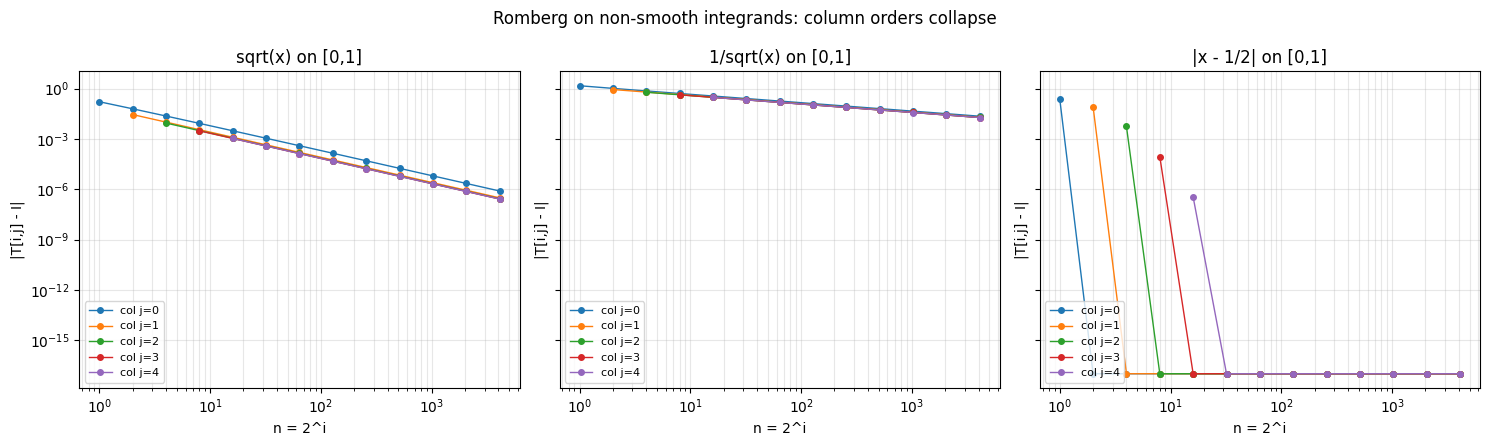

In [3]:
# 그림: 원본 세 문제의 열별 오차 (log-log)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (name, _, _, _, _) in zip(axes, problems):
    T, I = tables[name]
    for j in range(0, 5):
        err = np.abs(T[j:, j] - I)
        ax.loglog(n_vals[j:], np.maximum(err, 1e-17),
                  marker="o", markersize=4, linewidth=1.0,
                  label=f"col j={j}")
    ax.set_xlabel("n = 2^i")
    ax.set_ylabel("|T[i,j] - I|")
    ax.set_title(name)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8, loc="lower left")
plt.suptitle("Romberg on non-smooth integrands: column orders collapse", fontsize=12)
plt.tight_layout()
plt.show()


In [4]:
# 변수 변환 x = u^2  ->  dx = 2 u du
# sqrt(x) dx -> u * 2u du = 2 u^2 du
# 1/sqrt(x) dx -> (1/u) * 2u du = 2 du
def f_sqrt_xfm(u):
    return 2.0 * u * u

def f_invsqrt_xfm(u):
    return 2.0 * np.ones_like(u)

transformed = [
    ("sqrt(x) [x=u^2]",       f_sqrt_xfm,     0.0, 1.0, 2.0/3.0),
    ("1/sqrt(x) [x=u^2]",     f_invsqrt_xfm,  0.0, 1.0, 2.0),
]

x_tables = {}
for name, f, a, b, I in transformed:
    T = romberg_table(f, a, b, K_MAX)
    x_tables[name] = (T, I)
    print(f"{name:28s}   I = {I:.12f}   T[K,K] = {T[K_MAX, K_MAX]:.12f}    err = {abs(T[K_MAX,K_MAX]-I):.3e}")


sqrt(x) [x=u^2]                I = 0.666666666667   T[K,K] = 0.666666666667    err = 0.000e+00
1/sqrt(x) [x=u^2]              I = 2.000000000000   T[K,K] = 2.000000000000    err = 0.000e+00


In [5]:
# 변환된 적분의 열별 기울기 — 원본과 비교
slope_rows = []
for name, _, _, _, _ in transformed:
    T, I = x_tables[name]
    for j in range(0, 5):
        err = np.abs(T[j:, j] - I)
        s = column_slope(err, n_vals[j:])
        slope_rows.append({
            "problem (transformed)": name,
            "j": j,
            "slope": f"{s:+.3f}" if not np.isnan(s) else "n/a",
            "ideal smooth": f"-{2*(j+1)}",
        })
print("\n[After change of variables x = u^2 — column-wise slopes]\n")
print(pd.DataFrame(slope_rows).to_string(index=False))



[After change of variables x = u^2 — column-wise slopes]

problem (transformed)  j  slope ideal smooth
      sqrt(x) [x=u^2]  0 -2.000           -2
      sqrt(x) [x=u^2]  1    n/a           -4
      sqrt(x) [x=u^2]  2    n/a           -6
      sqrt(x) [x=u^2]  3    n/a           -8
      sqrt(x) [x=u^2]  4    n/a          -10
    1/sqrt(x) [x=u^2]  0    n/a           -2
    1/sqrt(x) [x=u^2]  1    n/a           -4
    1/sqrt(x) [x=u^2]  2    n/a           -6
    1/sqrt(x) [x=u^2]  3    n/a           -8
    1/sqrt(x) [x=u^2]  4    n/a          -10


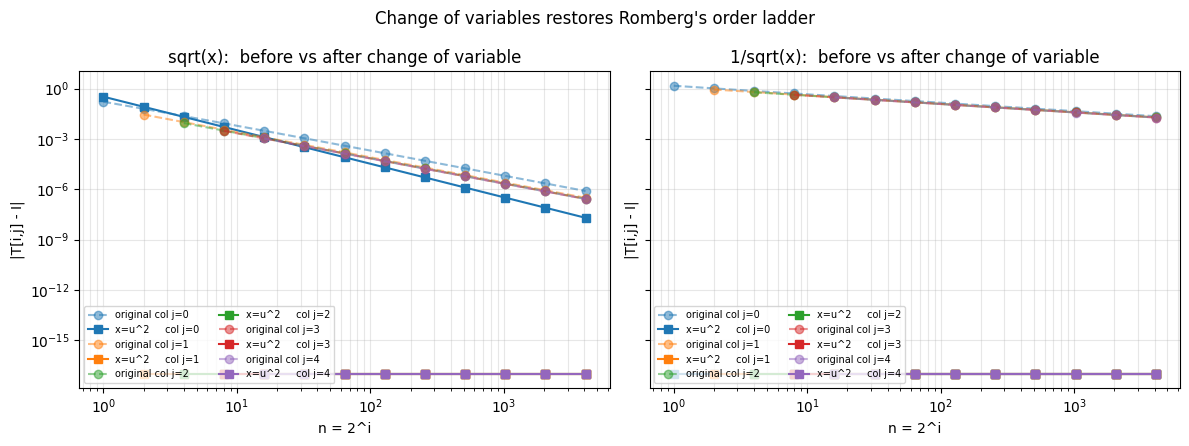

In [6]:
# 그림: 변환 전후 비교 (한 그래프에 같은 색깔로)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

pairs = [
    (axes[0], "sqrt(x) on [0,1]",  "sqrt(x) [x=u^2]",  "sqrt(x)"),
    (axes[1], "1/sqrt(x) on [0,1]", "1/sqrt(x) [x=u^2]", "1/sqrt(x)"),
]

for ax, orig, xfm, label in pairs:
    T_o, I = tables[orig]
    T_x, _ = x_tables[xfm]
    for j in range(0, 5):
        err_o = np.abs(T_o[j:, j] - I)
        err_x = np.abs(T_x[j:, j] - I)
        ax.loglog(n_vals[j:], np.maximum(err_o, 1e-17), "o--", color=f"C{j}", alpha=0.5,
                  label=f"original col j={j}")
        ax.loglog(n_vals[j:], np.maximum(err_x, 1e-17), "s-",  color=f"C{j}",
                  label=f"x=u^2     col j={j}")
    ax.set_xlabel("n = 2^i")
    ax.set_ylabel("|T[i,j] - I|")
    ax.set_title(label + ":  before vs after change of variable")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=7, loc="lower left", ncol=2)

plt.suptitle("Change of variables restores Romberg's order ladder", fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
# |x - 1/2| 의 짝수/홀수 i 차이 — 격자가 1/2 점을 통과하는 i 는 어떤가?
# 분할 n = 2^i.  중간점 1/2 가 그리드에 들어오려면 n 이 짝수면 충분.  n=2^i 는 항상 짝수 (i>=1) → 모든 i 에서 1/2 그리드 포함.
# 실제로는 그리드가 *내부 모서리* 1/2 를 만나면 사다리꼴이 *exact*.  그렇다면 모든 i 에서 정확해야 함 — 정말?
name = "|x - 1/2| on [0,1]"
T, I = tables[name]
df = pd.DataFrame({
    "i": np.arange(K_MAX + 1),
    "n": (2 ** np.arange(K_MAX + 1)).astype(int),
    "T[i,0]  trapezoid": T[:, 0],
    "err  |T[i,0] - I|": np.abs(T[:, 0] - I),
    "T[i,i]  diag":      np.array([T[i,i] for i in range(K_MAX+1)]),
    "err  |T[i,i] - I|": np.array([abs(T[i,i] - I) for i in range(K_MAX+1)]),
})
print(f"\n[|x-1/2| — Trapezoid is exact whenever 1/2 is on the grid]")
print("Since n = 2^i is even for i>=1, the breakpoint 1/2 = n/2 * h is always a grid node:\n")
print(df.to_string(index=False))
print("\n-> 0열은 i=0 (n=1) 에서만 부정확. 격자가 항상 1/2 를 통과 → trapezoid 가 *exact*.")
print("   따라서 모든 추가 열도 자명하게 exact (round-off 만).")



[|x-1/2| — Trapezoid is exact whenever 1/2 is on the grid]
Since n = 2^i is even for i>=1, the breakpoint 1/2 = n/2 * h is always a grid node:

 i    n  T[i,0]  trapezoid  err  |T[i,0] - I|  T[i,i]  diag  err  |T[i,i] - I|
 0    1       5.000000e-01       2.500000e-01  5.000000e-01       2.500000e-01
 1    2       2.500000e-01       0.000000e+00  1.666667e-01       8.333333e-02
 2    4       2.500000e-01       0.000000e+00  2.555556e-01       5.555556e-03
 3    8       2.500000e-01       0.000000e+00  2.499118e-01       8.818342e-05
 4   16       2.500000e-01       0.000000e+00  2.500003e-01       3.458173e-07
 5   32       2.500000e-01       0.000000e+00  2.500000e-01       3.380424e-10
 6   64       2.500000e-01       0.000000e+00  2.500000e-01       8.254508e-14
 7  128       2.500000e-01       0.000000e+00  2.500000e-01       0.000000e+00
 8  256       2.500000e-01       0.000000e+00  2.500000e-01       0.000000e+00
 9  512       2.500000e-01       0.000000e+00  2.500000e-01      

## 4. 결과 해석

1. **$\sqrt x$** — Romberg 표의 *모든* 열의 기울기가 $\sim -1.5$ — Euler–Maclaurin 의 $h^2$ 항이
   *없기* 때문에 $4^j$ 점근으로 빼봐도 *같은 점근* 의 잔차가 남는다. Richardson 의 *공기를 뺀 풍선* 만 부풀린다.
2. **$1/\sqrt x$** — Day 19 의 적응형 Simpson 도 어려워했던 함수. Romberg 는 $\sim -0.5$ 기울기로
   *모든 열이 동일* — 가장 극단적인 *외삽 실패*.
3. **$|x - 1/2|$** — 분할 $n = 2^i$ 가 *항상* 중간점 $1/2$ 를 그리드 노드로 포함 → 사다리꼴이
   *우연히 정확*. 따라서 Romberg 도 자명하게 정확 — *부드러움 위반이 그리드와 정렬* 되면 외삽이
   필요 없다는 *경계 사례*.
4. **변수 변환 $x = u^2$** — $\sqrt x$ 는 다항식 $2u^2$ 로, $1/\sqrt x$ 는 *상수* $2$ 로 환원.
   Problem 1 의 *완벽한 차수 사다리* ($-2, -4, -6, \ldots$) 가 부활. 상수 적분은 *모든 $n$ 에서
   기계 정밀도* — Romberg 의 정의역에서 *가장 행복한* 입력.
5. **변환과 적응형의 분업** — 적응형 Simpson 은 *어디서* 자세히 봐야 할지 모르고 *데이터로* 배운다.
   변수 변환은 *사람의 지식* (특이점의 형태) 을 입력해 *수학적으로* 부드럽게 만든다.
   둘은 상보적 — 모르면 적응형, 알면 변환.
6. **Romberg 의 진단 능력** — *열별 측정 기울기가 모두 같다* 는 사실 그 자체가
   "$h^2$ 항이 없다" 는 신호. 즉 Romberg 표는 *해* 만 주는 게 아니라 *부드러움 진단* 도 함께 준다.

> **결론**: Romberg 의 차수 사다리는 *부드러움의 회계* 다.
> $f$ 가 짝수 차의 Euler–Maclaurin 전개를 지원하면 *완벽*, 깨지면 *완전 실패*.
> 변수 변환은 그 회계를 *복원* 하고, 적응형은 *우회* 한다 — 같은 문제의 두 다른 답.

### 다음 (Day 21)
**§5.5 — Gaussian Quadrature**. 균등 분할로 $\mathcal O(h^4)$ 가 Simpson 의 한계였다면,
*분할점 자체* 를 자유롭게 둘 수 있을 때 차수가 어디까지 올라갈까? — $n$ 개 점으로 $2n-1$ 차 다항식 정확,
즉 *비할당 점근 차수* 의 *2배 점프*. Legendre 다항식의 영점, 그리고 *가중* 직교성.
